<a href="https://colab.research.google.com/github/StephanyMejia25/MejiaStephany2524022017/blob/main/archivos/AnalisisdeCorrelaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# 1. Cargar datos
url= "https://raw.githubusercontent.com/StephanyMejia25/MejiaStephany2524022017/refs/heads/main/archivos/clave_A_correlacion.csv"
df = pd.read_csv(url)
df.head()


,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,A-C0001,37,468,4,36.45,8.73,1,7,22.02,297.03
1,A-C0002,27,1076,8,63.31,9.15,0,6,24.89,524.34
2,A-C0003,19,948,5,44.25,8.33,0,1,26.58,181.14
3,A-C0004,41,832,8,63.11,9.90,0,5,16.22,532.66
4,A-C0005,30,1287,6,86.49,7.83,1,4,20.42,557.44


In [3]:
# 2. Revision inicial
print("Dimensiones del dataset:")
print(df.shape)

print("Primeras filas:")
print(df.head())

print("Informacion general:")
print(df.info())


Dimensiones del dataset:
(221, 10)
Primeras filas:
  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    A-C0001    37                 468                  4            36.45   
1    A-C0002    27                1076                  8            63.31   
2    A-C0003    19                 948                  5            44.25   
3    A-C0004    41                 832                  8            63.11   
4    A-C0005    30                1287                  6            86.49   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          8.73         1        7             22.02         297.03  
1          9.15         0        6             24.89         524.34  
2          8.33         0        1             26.58         181.14  
3          9.90         0        5             16.22         532.66  
4          7.83         1        4             20.42         557.44  
Informacion general:
<class 'pandas.core.frame.DataFrame'>
R

In [4]:
# 3. Revision de valores nulos
print("Valores nulos:")
print(df.isnull().sum())

# 4. Revision de duplicados
print("Registros duplicados:")
print(df.duplicated().sum())

# 5. Estadistica descriptiva
print("Estadistica descriptiva:")
print(df.describe())


Valores nulos:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64
Registros duplicados:
1
Estadistica descriptiva:
             edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
count  221.000000          221.000000         221.000000       220.000000   
mean    33.981900          853.868778           7.018100        55.187273   
std     10.037187          251.337379           3.046554        16.185683   
min     18.000000          300.000000           1.000000        14.660000   
25%     27.000000          692.000000           6.000000        42.662500   
50%     34.000000          854.000000           7.000000        55.585000   
75%     41.000000         1012.000000           8.000000        67.195000   
max     60.000000         1517.000000          27.000000        96.

In [6]:
# 6. Deteccion de valores atipicos
variables_numericas = [
    "edad",
    "ingresos_mensuales",
    "frecuencia_compra",
    "ticket_promedio",
    "satisfaccion",
    "reclamos",
    "uso_app",
    "tiempo_respuesta",
    "consumo_total"
]

print("Revision de valores atipicos:")
for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviacion estandar:", round(desviacion, 2))
    print("Limite inferior:", round(limite_inferior, 2))
    print("Limite superior:", round(limite_superior, 2))
    print("Cantidad de valores atipicos:", len(atipicos))
    print("-" * 40)

Revision de valores atipicos:
Variable: edad
Media: 33.98
Desviacion estandar: 10.04
Limite inferior: 13.91
Limite superior: 54.06
Cantidad de valores atipicos: 3
----------------------------------------
Variable: ingresos_mensuales
Media: 853.87
Desviacion estandar: 251.34
Limite inferior: 351.19
Limite superior: 1356.54
Cantidad de valores atipicos: 13
----------------------------------------
Variable: frecuencia_compra
Media: 7.02
Desviacion estandar: 3.05
Limite inferior: 0.92
Limite superior: 13.11
Cantidad de valores atipicos: 4
----------------------------------------
Variable: ticket_promedio
Media: 55.19
Desviacion estandar: 16.19
Limite inferior: 22.82
Limite superior: 87.56
Cantidad de valores atipicos: 12
----------------------------------------
Variable: satisfaccion
Media: 7.54
Desviacion estandar: 1.16
Limite inferior: 5.22
Limite superior: 9.86
Cantidad de valores atipicos: 11
----------------------------------------
Variable: reclamos
Media: 1.56
Desviacion estandar: 1

In [8]:
# 7. Matriz de correlacion
matriz_correlacion = df.select_dtypes(include=['number']).corr()

print("Matriz de correlacion:")
print(matriz_correlacion.round(3))

Matriz de correlacion:
                     edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000              -0.008             -0.039   
ingresos_mensuales -0.008               1.000              0.053   
frecuencia_compra  -0.039               0.053              1.000   
ticket_promedio     0.134               0.556              0.103   
satisfaccion       -0.105              -0.005              0.247   
reclamos            0.049               0.029             -0.121   
uso_app             0.028              -0.094              0.574   
tiempo_respuesta    0.062              -0.065             -0.332   
consumo_total       0.057               0.300              0.834   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                          0.134        -0.105     0.049    0.028   
ingresos_mensuales            0.556        -0.005     0.029   -0.094   
frecuencia_compra             0.103         0.247    -0.121    0.574   
ticket_p

In [9]:
print("\nCorrelaciones con consumo_total:")
print(matriz_correlacion["consumo_total"].sort_values(ascending=False).round(3))


Correlaciones con consumo_total:
consumo_total         1.000
frecuencia_compra     0.834
ticket_promedio       0.551
uso_app               0.543
satisfaccion          0.328
ingresos_mensuales    0.300
edad                  0.057
reclamos             -0.209
tiempo_respuesta     -0.380
Name: consumo_total, dtype: float64


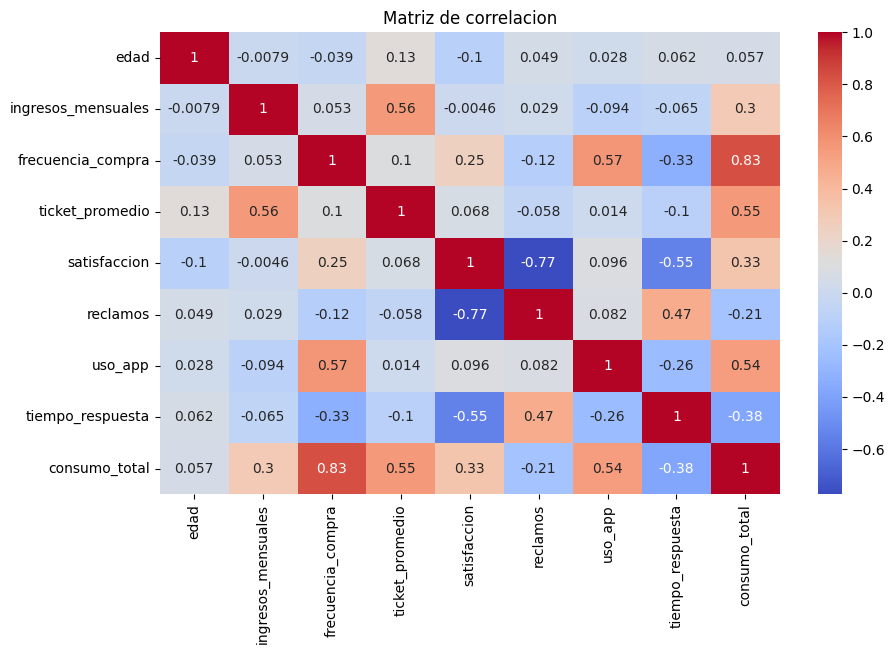

In [10]:
#Este bloque de código genera un mapa de calor para visualizar la matriz de correlación.
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm")
plt.title("Matriz de correlacion")
plt.show()


In [11]:
# Identificar las correlaciones positivas más importantes
corr_positivas = matriz_correlacion.unstack().sort_values(ascending=False)
corr_positivas = corr_positivas[corr_positivas != 1.0] # Excluir correlaciones de la variable consigo misma
corr_positivas = corr_positivas[corr_positivas > 0.5] # Filtra para ver las correlaciones positivas fuertes

print("\nCorrelaciones Positivas más Importantes (>0.5):")
print(corr_positivas.drop_duplicates().head(5)) # Mostrar las 5 principales, evitando duplicados simétricos


Correlaciones Positivas más Importantes (>0.5):
frecuencia_compra  consumo_total         0.833677
                   uso_app               0.574399
ticket_promedio    ingresos_mensuales    0.555589
consumo_total      ticket_promedio       0.551161
uso_app            consumo_total         0.542587
dtype: float64


In [12]:
# Identificar las correlaciones negativas más importantes
corr_negativas = matriz_correlacion.unstack().sort_values(ascending=True)
corr_negativas = corr_negativas[corr_negativas < -0.5] # Filtra para ver las correlaciones negativas fuertes

print("\nCorrelaciones Negativas más Importantes (<-0.5):")
print(corr_negativas.drop_duplicates().head(5)) # Mostrar las 5 principales, evitando duplicados simétricos


Correlaciones Negativas más Importantes (<-0.5):
reclamos      satisfaccion       -0.773891
satisfaccion  tiempo_respuesta   -0.546874
dtype: float64


## Análisis de Relaciones entre Variables

Basándonos en la matriz de correlación, podemos identificar varias relaciones clave:

1.  **`consumo_total` y `frecuencia_compra` (Correlación Positiva Fuerte: 0.834):** Existe una relación muy fuerte y positiva entre la frecuencia con la que un cliente compra y su consumo total. Esto sugiere que los clientes que compran más a menudo también gastan más en general. Es una relación intuitiva: a mayor interacción, mayor gasto.

2.  **`consumo_total` y `ticket_promedio` (Correlación Positiva Fuerte: 0.551):** También observamos una correlación positiva fuerte entre el ticket promedio y el consumo total. Esto indica que no solo la frecuencia de compra influye, sino también el valor promedio de cada transacción. Los clientes que gastan más en cada compra contribuyen significativamente al consumo total.

3.  **`satisfaccion` y `reclamos` (Correlación Negativa Fuerte: -0.774):** Esta es una correlación negativa muy fuerte y lógica. A medida que la satisfacción de un cliente aumenta, el número de reclamos tiende a disminuir drásticamente. Esto subraya la importancia de la satisfacción del cliente para reducir problemas y quejas.

4.  **`satisfaccion` y `tiempo_respuesta` (Correlación Negativa Fuerte: -0.547):** Hay una correlación negativa fuerte entre la satisfacción del cliente y el tiempo de respuesta. Esto significa que cuanto menor es el tiempo de respuesta (es decir, más rápida es la atención), mayor es la satisfacción del cliente. La eficiencia en el servicio al cliente es crucial para mantener a los clientes contentos.

## Conclusiones e Implicaciones para la Empresa

Estas relaciones proporcionan información valiosa para la empresa:

*   **Fidelización y Consumo:** La fuerte correlación entre `frecuencia_compra` y `consumo_total` (0.834) sugiere que la empresa debería enfocarse en estrategias de fidelización para aumentar la recurrencia de compra. Programas de lealtad, ofertas personalizadas o suscripciones podrían incentivar a los clientes a comprar más seguido, lo que se traduciría directamente en un mayor consumo total.

*   **Optimización del Ticket Promedio:** La relación entre `ticket_promedio` y `consumo_total` (0.551) indica que la empresa puede aumentar el consumo general alentando a los clientes a gastar más en cada visita. Estrategias como ventas cruzadas (cross-selling), ventas adicionales (up-selling), o paquetes de productos podrían ser efectivas.

*   **Prioridad en la Satisfacción:** La relación inversa entre `satisfaccion` y `reclamos` (-0.774) y entre `satisfaccion` y `tiempo_respuesta` (-0.547) resalta la satisfacción del cliente como un pilar fundamental. Invertir en mejorar la experiencia del cliente, la calidad del producto/servicio y optimizar los tiempos de respuesta del soporte al cliente no solo reducirá los reclamos, sino que también aumentará la lealtad y retención.